In [68]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import List, Tuple, Optional, Dict
from math import comb 



In [69]:
# Configuración reproducible
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Parámetros del problema
MIN_ESPACIO = 4.0          # La separación mínima permitida entre aviones, medida en minutos de tiempo de vuelo.
ESPACIO_OBJETIVO = 5.0       # Valor objetivo de separación: los aviones intentan mantener 5 minutos de distancia como buffer de seguridad adicional, si están muy cerca, el avión de atrás baja la velocidad hasta aumentar ese gap a 5.
RADAR_NM = 100.0           # Distancia en millas náuticas (mn) a la que los aviones entran en el radar de Aeroparque (AEP). Cada avión aparece “en la simulación” en este punto inicial.
VELOCIDAD_DE_RETROCESO_KTS = 200.0  # Si un avión no puede mantener la separación (porque debería ir más lento que el mínimo permitido), se sale de la fila y vuela hacia atrás a 200 nudos hasta encontrar un hueco (o salirse del radar a Montevideo, según el caso). Es la velocidad que se usa en ese modo “retrocediendo”.
NUDOS_A_MNxMIN = 1.0 / 60.0  # conversión nudos -> mn/min

In [77]:
def rango_de_velocidad_permitido(distancia_a_mn: float) -> Tuple[float, float]:
    """Devuelve (min_kts, max_kts) permitidos según la tabla del enunciado."""
    if distancia_a_mn > 100.0:
        return 300.0, 500.0
    elif distancia_a_mn > 50.0:
        return 250.0, 300.0   # 100..50
    elif distancia_a_mn > 15.0:
        return 200.0, 250.0   # 50..15
    elif distancia_a_mn > 5.0:
        return 150.0, 200.0   # 15..5
    else:
        return 120.0, 150.0   # 5..0

In [80]:
def tiempo_libre_ideal() -> float:
    """
    Tiempo ideal (en minutos) para descender desde RADAR_NM hasta la pista,
    volando siempre a la velocidad máxima permitida en cada tramo.
    """
    # límites de los tramos en mn
    tramos = [100, 50, 15, 5, 0]
    tiempo = 0.0

    for i in range(len(tramos) - 1):
        d1, d2 = tramos[i], tramos[i+1]
        distancia = d1 - d2
        _, vmax = rango_de_velocidad_permitido((d1 + d2) / 2)  # tomo el vmax del tramo
        tiempo += distancia / (vmax / 60.0)  # mn / (mn/min) = min

    return tiempo


In [ ]:
@dataclass
class Avion:
    avion_id: int
    tiempo_de_aparicion: int
    distancia_a_mn: float = RADAR_NM
    velocidad_kts: float = 0.0
    estado: str = "acercandose"  # acercandose | retrocediendo | desviado | aterrizado
    tiempo_de_aterrizaje: Optional[int] = None
    tiempo_de_desvio: Optional[int] = None
    historial_de_tiempos: List[int] = field(default_factory=list)
    historial_de_distancias: List[float] = field(default_factory=list)
    
    


    def registrar(self, t: int):
        """
        Guarda en las listas de trayectoria el tiempo actual y la distancia 
        del avión a la pista.
        """
        self.historial_de_tiempos.append(t) #Agrega el instante actual t a la lista historial_de_tiempos.
        self.historial_de_distancias.append(self.distancia_a_mn) #Agrega la distancia del avion a la pista en el momento t a la lista historial_de_distancias.

    def avanzar(self, t: int):
        if self.estado != "acercandose":
            return
        _, vmax = rango_de_velocidad_permitido(self.distancia_a_mn)
        self.velocidad_kts = vmax
        self.distancia_a_mn -= self.velocidad_kts * NUDOS_A_MNxMIN
        self.registrar(t)
        if self.distancia_a_mn <= 0:
            self.distancia_a_mn = 0
            self.estado = "aterrizado"
            self.tiempo_de_aterrizaje = t

    
   
    
    

In [81]:
class AEP:
    """
    Simulación de arribos y aproximación a AEP (inciso 1).
    En este modo todos los aviones vuelan libres, sin congestión.
    """
    def __init__(self, lam: float, T_minutes: int): 
        assert 0.0 < lam <= 1.0, "λ debe estar entre 0 y 1"
        self.lam = lam
        self.T = T_minutes
        self.aviones: List[Avion] = []
        self.next_id = 1


    def generar_si_llega(self, t: int):
        """Genera un nuevo avión en el radar si ocurre un arribo en este minuto."""
        if rng.random() < self.lam:
            _, max_kts = rango_de_velocidad_permitido(RADAR_NM)
            avion = Avion(
                avion_id=self.next_id,
                tiempo_de_aparicion=t,
                distancia_a_mn=RADAR_NM,
                velocidad_kts=max_kts,
                estado="acercandose"
            )
            self.aviones.append(avion)
            self.next_id += 1

    def actualizacion_de_posicion(self, t: int):
        """Avanza todos los aviones usando siempre vmax (no hay congestión en inciso 1)."""
        for avion in self.aviones:
            if avion.estado == "acercandose":
                _, vmax = rango_de_velocidad_permitido(avion.distancia_a_mn)
                avion.velocidad_kts = vmax
                avion.distancia_a_mn -= avion.velocidad_kts * NUDOS_A_MNxMIN
                if avion.distancia_a_mn <= 0:
                    avion.distancia_a_mn = 0
                    avion.estado = "aterrizado"
                    avion.tiempo_de_aterrizaje = t

            avion.registrar(t)

    def run(self) -> Dict[str, int]:
        """Corre la simulación completa de T minutos (inciso 1)."""
        for t in range(self.T):
            self.generar_si_llega(t)
            self.actualizacion_de_posicion(t)
        return {
            "aparecieron": len(self.aviones),
            "aterrizado": sum(1 for a in self.aviones if a.estado == "aterrizado"),
            "sigue_acercandose": sum(1 for a in self.aviones if a.estado == "acercandose"),
        }


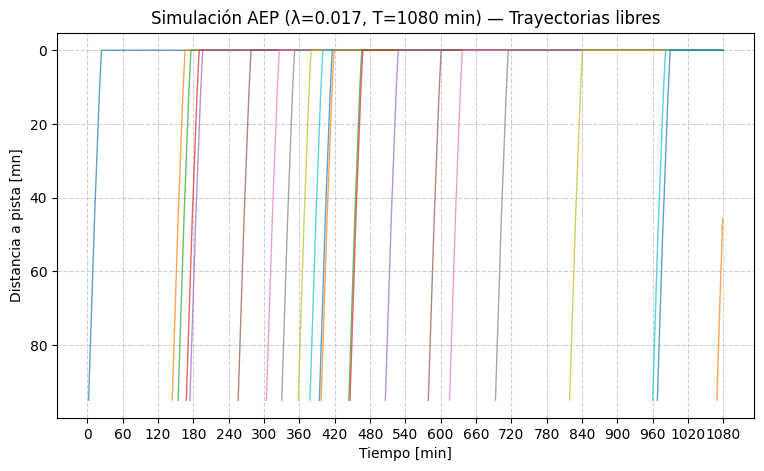

Resumen de la corrida:
- aparecieron: 22
- aterrizado: 21
- sigue_acercandose: 1


In [82]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

def run_and_plot(lam: float = 0.017, T_minutes: int = 1080):
    # Inicializar simulación (inciso 1 → congestion=0)
    sim = AEP(lam=lam, T_minutes=T_minutes)
    summary = sim.run()

    # Visualización: tiempo vs distancia (una línea por avión)
    plt.figure(figsize=(9, 5))
    for avion in sim.aviones:
        tiempos_arr = np.array(avion.historial_de_tiempos)
        distancias_arr = np.array(avion.historial_de_distancias)
        if len(tiempos_arr) > 0:
            plt.plot(tiempos_arr, distancias_arr, linewidth=1, alpha=0.7)

    plt.title(f"Simulación AEP (λ={lam}, T={T_minutes} min) — Trayectorias libres")
    plt.xlabel("Tiempo [min]")
    plt.ylabel("Distancia a pista [mn]")
    plt.gca().invert_yaxis()  # más intuitivo: arriba lejos, abajo pista
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.gca().xaxis.set_major_locator(ticker.MultipleLocator(60))  # marcas cada hora
    plt.show()

    # Resumen de la corrida
    print("Resumen de la corrida:")
    for k, v in summary.items():
        print(f"- {k}: {v}")

    return sim, summary

_ = run_and_plot(lam=0.017, T_minutes=1080)


2) Si el promedio de arribos es de 1 avión por hora, cuánto es λ?

In [30]:

tiempo_en_min = 60
cant_aviones = 1

lam = cant_aviones / tiempo_en_min
print(f"λ = {lam:.6f} (≈ 1/60)")


λ = 0.016667 (≈ 1/60)


3) Bajo este valor de λ y en base a una simulación suficientemente larga estimá la probabilidad de que lleguen 5 aviones en una hora. Podés verificar tu resultado de manera analítica?

In [75]:
import numpy as np
import scipy.stats as st


def prob_5_aviones(lam=1/60, N=100000):
    """Estimación Monte Carlo de P(N=5) en 1h con λ dado."""
    # Simulamos 'runs' horas → cada hora = Binomial(60, lam)
    counts = np.random.binomial(60, lam, size=N)
    
    # Estimación empírica: proporción de horas con exactamente 5 aviones
    Proba_Montecarlo = np.mean(counts == 5)
    
    # Teórico: Poisson con media μ = λ*60 = 1
    Proba_teorica = st.poisson.pmf(5, mu=lam*60)
    return Proba_Montecarlo, Proba_teorica

np.random.seed(22)   # fijar semilla reproducible
Proba_Montecarlo, Proba_teorica = prob_5_aviones()

print("===== Punto 3 =====")
print(f"Probabilidad empírica (Monte Carlo): {Proba_Montecarlo:.5f}")
print(f"Probabilidad teórica (Poisson(1)):   {Proba_teorica:.5f}")


===== Punto 3 =====
Probabilidad empírica (Monte Carlo): 0.00290
Probabilidad teórica (Poisson(1)):   0.00307


# Punto 4 - Experimentos por distintos λ: congestión, atrasos y desvíos
## Ampliamos el simulador para medir congestión, atrasos vs. vuelo libre y desvíos.


In [79]:
RNG_SEED = 42
rng = np.random.default_rng(RNG_SEED)

# Parámetros del problema
MIN_ESPACIO = 4.0          # separación mínima permitida [min]
ESPACIO_OBJETIVO = 5.0     # separación objetivo [min]
RADAR_NM = 100.0           # distancia inicial al radar [mn]
VELOCIDAD_DE_RETROCESO_KTS = 200.0  # velocidad al retroceder
NUDOS_A_MN_POR_MIN = 1.0 / 60.0     # conversión kts → mn/min

def rango_de_velocidad_permitido(distancia_a_mn: float) -> Tuple[float, float]:
    """Devuelve (min_kts, max_kts) según tramo de distancia."""
    if distancia_a_mn > 100.0:
        return 300.0, 500.0
    elif distancia_a_mn > 50.0:
        return 250.0, 300.0   # 100..50
    elif distancia_a_mn > 15.0:
        return 200.0, 250.0   # 50..15
    elif distancia_a_mn > 5.0:
        return 150.0, 200.0   # 15..5
    else:
        return 120.0, 150.0   # 5..0

# -----------------------------
# Clase Avion
# -----------------------------
@dataclass
class Avion:
    avion_id: int
    tiempo_de_aparicion: int
    distancia_a_mn: float = RADAR_NM
    velocidad_kts: float = 0.0
    estado: str = "acercandose"  # acercandose | retrocediendo | desviado | aterrizado
    tiempo_de_aterrizaje: Optional[int] = None
    tiempo_de_desvio: Optional[int] = None
    historial_de_tiempos: List[int] = field(default_factory=list)
    historial_de_distancias: List[float] = field(default_factory=list)
    congestiones: int = 0

    def registrar(self, t: int):
        self.historial_de_tiempos.append(t)
        self.historial_de_distancias.append(self.distancia_a_mn)

    def tiempo_estimado_de_llegada(self) -> Optional[float]:
        if self.estado != "acercandose" or self.velocidad_kts <= 0.0:
            return None
        return self.distancia_a_mn / (self.velocidad_kts * NUDOS_A_MN_POR_MIN)
    
    def tiempo_libre_teorico(self) -> float:
        """Tiempo ideal de descenso desde 100 mn hasta 0, sin congestión."""
        segments = [
            (50, 300),   # 100 → 50 mn
            (35, 250),   # 50 → 15 mn
            (10, 200),   # 15 → 5 mn
            (5, 150)     # 5 → 0 mn
        ]
        return sum(dist / (vmax/60) for dist, vmax in segments)


# -----------------------------
# Clase AEP
# -----------------------------
class AEP:
    """Simulación de arribos y aproximación a AEP con congestión (inciso 4)."""
    def __init__(self, lam: float, T_minutes: int): 
        assert 0.0 < lam <= 1.0, "λ debe estar entre 0 y 1"
        self.lam = lam
        self.T = T_minutes
        self.aviones: List[Avion] = []
        self.next_id = 1

    def generar_si_llega(self, t: int):
        if rng.random() < self.lam:
            _, vmax = rango_de_velocidad_permitido(RADAR_NM)
            avion = Avion(
                avion_id=self.next_id,
                tiempo_de_aparicion=t,
                distancia_a_mn=RADAR_NM,
                velocidad_kts=vmax,
                estado="acercandose"
            )
            self.aviones.append(avion)
            self.next_id += 1

    def controlar_separacion(self, t: int):
        """Ajusta velocidades para mantener separación mínima de 4 min."""
        acercandose_: List[Tuple[float, Avion]] = []
        for avion in self.aviones:
            if avion.estado == "acercandose":
                eta = avion.tiempo_estimado_de_llegada()
                if eta is not None:
                    acercandose_.append((t + eta, avion))
        acercandose_.sort(key=lambda x: x[0])

        for i in range(len(acercandose_) - 1):
            _, lider = acercandose_[i]
            _, seguidor = acercandose_[i+1]

            v_min, v_max = rango_de_velocidad_permitido(seguidor.distancia_a_mn)
            gap = (seguidor.tiempo_estimado_de_llegada() or 1e9) - (lider.tiempo_estimado_de_llegada() or 0)

            if gap < MIN_ESPACIO:
                proposed = min(v_max, max(0.0, lider.velocidad_kts - 20))
                seguidor.congestiones += 1
                if proposed < v_min:
                    seguidor.estado = "retrocediendo"
                    seguidor.velocidad_kts = VELOCIDAD_DE_RETROCESO_KTS
                else:
                    seguidor.velocidad_kts = proposed
            elif gap >= ESPACIO_OBJETIVO:
                seguidor.velocidad_kts = v_max
            # entre 4 y 5 → mantiene velocidad actual

    def actualizacion_de_posicion(self, t: int):
        for avion in self.aviones:
            if avion.estado == "acercandose":
                v_min, v_max = rango_de_velocidad_permitido(avion.distancia_a_mn)
                avion.velocidad_kts = max(min(avion.velocidad_kts, v_max), v_min)
                avion.distancia_a_mn -= avion.velocidad_kts * NUDOS_A_MN_POR_MIN
                if avion.distancia_a_mn <= 0:
                    avion.distancia_a_mn = 0
                    avion.estado = "aterrizado"
                    avion.tiempo_de_aterrizaje = t

            elif avion.estado == "retrocediendo":
                avion.distancia_a_mn += VELOCIDAD_DE_RETROCESO_KTS * NUDOS_A_MN_POR_MIN
                if avion.distancia_a_mn >= RADAR_NM + 1e-6:
                    avion.estado = "desviado"
                    avion.tiempo_de_desvio = t

            avion.registrar(t)

    def run(self) -> Dict[str, int]:
        for t in range(self.T):
            self.generar_si_llega(t)
            self.controlar_separacion(t)
            self.actualizacion_de_posicion(t)
        return {
            "aparecieron": len(self.aviones),
            "aterrizados": sum(1 for a in self.aviones if a.estado == "aterrizado"),
            "desviados": sum(1 for a in self.aviones if a.estado == "desviado"),
            "retrocediendo": sum(1 for a in self.aviones if a.estado == "retrocediendo"),
            "acercandose": sum(1 for a in self.aviones if a.estado == "acercandose"),
        }

# -----------------------------
# Monte Carlo para inciso 4
# -----------------------------
def montecarlo_inciso4(lam_list, dias=200, T=1080):
    resultados = []
    for lam in lam_list:
        tot_arribos, tot_aterr, tot_desv = 0, 0, 0
        tot_cong_aviones, tot_cong_eventos = 0, 0
        atrasos_all = []

        for _ in range(dias):
            sim = AEP(lam=lam, T_minutes=T)
            summary = sim.run()

            tot_arribos += summary["aparecieron"]
            tot_aterr += summary["aterrizados"]
            tot_desv += summary["desviados"]

            # congestiones
            tot_cong_aviones += sum(a.congestiones > 0 for a in sim.aviones)
            tot_cong_eventos += sum(a.congestiones for a in sim.aviones)

            # atraso = diferencia entre aterrizaje real y “libre”
            for a in sim.aviones:
                if a.estado == "aterrizado" and a.tiempo_de_aterrizaje is not None:
                    libre = a.tiempo_de_aparicion + a.tiempo_libre_teorico()
                    atraso = max(0, a.tiempo_de_aterrizaje - libre)
                    atrasos_all.append(atraso)


        # proporciones
        p_cong = tot_cong_aviones / tot_arribos if tot_arribos else 0
        p_desv = tot_desv / tot_arribos if tot_arribos else 0

        # errores
        e_cong = np.sqrt(p_cong * (1 - p_cong) / tot_arribos) if tot_arribos else 0
        e_desv = np.sqrt(p_desv * (1 - p_desv) / tot_arribos) if tot_arribos else 0
        m_atraso = np.mean(atrasos_all) if atrasos_all else 0
        e_atraso = np.std(atrasos_all) / np.sqrt(len(atrasos_all)) if atrasos_all else 0

        resultados.append({
            "λ": lam,
            "arribos_prom": tot_arribos / dias if dias else 0,
            "p_cong": p_cong, "e_cong": e_cong,
            "cong_eventos_prom": tot_cong_eventos / tot_arribos if tot_arribos else 0,
            "m_atraso": m_atraso, "e_atraso": e_atraso,
            "p_desv": p_desv, "e_desv": e_desv,
            "p_aterr": tot_aterr / tot_arribos if tot_arribos else 0
        })
    return resultados

# -----------------------------
# Ejecución
# -----------------------------
lam_list = [0.02, 0.1, 0.2, 0.5, 1.0]
np.random.seed(2025)

res = montecarlo_inciso4(lam_list, dias=200)

print("===== Resultados Punto 4 =====")
print("λ\tArribos/día\tCongestión ± err\tAtraso prom. ± err\tDesvíos ± err\tAterrizajes")
for r in res:
    print(f"{r['λ']:.2f}\t{r['arribos_prom']:.2f}\t"
          f"{r['p_cong']:.3f}±{r['e_cong']:.3f}\t"
          f"{r['m_atraso']:.2f}±{r['e_atraso']:.2f}\t"
          f"{r['p_desv']:.3f}±{r['e_desv']:.3f}\t"
          f"{r['p_aterr']:.3f}")


===== Resultados Punto 4 =====
λ	Arribos/día	Congestión ± err	Atraso prom. ± err	Desvíos ± err	Aterrizajes
0.02	21.38	0.104±0.005	0.00±0.00	0.098±0.005	0.880
0.10	108.20	0.424±0.003	0.01±0.00	0.357±0.003	0.623
0.20	215.46	0.646±0.002	0.04±0.00	0.518±0.002	0.465
0.50	539.14	0.862±0.001	0.12±0.00	0.740±0.001	0.248
1.00	1080.00	0.899±0.001	0.30±0.00	0.797±0.001	0.195


In [33]:


# 1) (Si no lo tenés) tiempo ideal de vuelo libre desde 100 mn
def _free_flight_minutes_from_100nm():
    NM_PER_MIN_FROM_KTS = 1.0/60.0
    segs = [
        (100-50, 300.0),  # 100→50 a 300 kts
        (50-15, 250.0),   # 50→15 a 250 kts
        (15-5, 200.0),    # 15→5 a 200 kts
        (5-0, 150.0),     # 5→0 a 150 kts
    ]
    t = 0.0
    for dist_nm, kts in segs:
        t += dist_nm / (kts * (1.0/60.0))
    return t

FREE_FLIGHT_MIN: float  # hint para que Pylance sepa que existe
print(FREE_FLIGHT_MIN)

try:
    FREE_FLIGHT_MIN
except NameError:
    FREE_FLIGHT_MIN = _free_flight_minutes_from_100nm()



# 3) Helpers
def mean_se(values):
    arr = np.array(values, dtype=float)
    m = float(arr.mean()) if arr.size else float("nan")
    se = float(arr.std(ddof=1)/np.sqrt(arr.size)) if arr.size > 1 else float("nan")
    return m, se

def summarize_sim(sim) -> Dict[str, float]:
    aviones: List[Avion] = getattr(sim, "aviones", [])
    aparecieron: int = len(aviones)

    retrocediendo    = [a for a in aviones if a.estado == "retrocediendo"]
    aterrizados = [a for a in aviones if a.estado == "aterrizado"]
    desviados   = [a for a in aviones if a.estado == "desviado"]
    terminados  = aterrizados + desviados

    # Tasa de congestión (flag congestionado)
    tasa_de_congestion = sum(a.congestiones for a in aviones)


    # Atraso promedio (solo aterrizados)
    delays: List[float] = []
    for a in aterrizados:
        if a.tiempo_de_aparicion is not None and a.tiempo_de_aterrizaje is not None:
            delay = a.tiempo_de_aterrizaje - (a.tiempo_de_aparicion + FREE_FLIGHT_MIN)
            delays.append(max(0.0, delay))
    avg_delay_min = float(np.mean(delays)) if delays else float("nan")

    # Tasa de desvío condicional a haber terminado
    tasa_de_desvio = len(desviados) / len(terminados) if terminados else float("nan")

    return {
        "aparecieron": float(aparecieron),
        "aterrizados": float(len(aterrizados)),
        "desviados": float(len(desviados)),
        "tasa_de_desvio": tasa_de_desvio,
        "tasa_de_congestion": tasa_de_congestion,
        "avg_delay_min": avg_delay_min,
    }


def evaluate_lambda(lam, reps=50, T_minutes=1080, show_example_plot=False):
    """Corre varias simulaciones y reporta media ± SE de las métricas."""
    tasa_de_desvio, tasa_de_congestion, delays = [], [], []
    lista_de_aterrizados, lista_de_apariciones = [], []

    for _ in range(reps):
        sim = AEP(lam=lam, T_minutes=T_minutes)
        _ = sim.run()
        m = summarize_sim(sim)
        lista_de_apariciones.append(m["aparecieron"])
        lista_de_aterrizados.append(m["aterrizados"])
        tasa_de_desvio.append(m["tasa_de_desvio"])
        tasa_de_congestion.append(m["tasa_de_congestion"])
        delays.append(m["avg_delay_min"])


    sm, _  = mean_se(lista_de_apariciones)
    lm, _  = mean_se(lista_de_aterrizados)
    drm, drse = mean_se(tasa_de_desvio)
    cgm, cgse = mean_se(tasa_de_congestion)
    adm, adse = mean_se(delays)

    print(f"\nλ={lam} | reps={reps} | T={T_minutes} min")
    print(f"- Apariciones: {sm:.1f}   Aterrizados: {lm:.1f}")
    print(f"- Congestión: {cgm:.3f} ± {cgse:.3f}")
    print(f"- Atraso promedio (solo aterrizados): {adm:.3f} ± {adse:.3f} min")
    print(f"- Desvíos (fracción sobre terminados): {drm:.3f} ± {drse:.3f}")


    if show_example_plot:
        # una corrida de ejemplo para ver las trayectorias
        sim = AEP(lam=lam, T_minutes=360)
        _ = sim.run()
        plt.figure(figsize=(9,4))
        for avion in sim.aviones:
            t = np.array(getattr(avion, "historial_de_tiempos", []))
            d = np.array(getattr(avion, "historial_de_distancia", []))
            if t.size and d.size:
                plt.plot(t, d, lw=0.7)
        plt.title(f"Trayectorias tiempo–distancia (ejemplo, λ={lam})")
        plt.xlabel("Tiempo [min]"); plt.ylabel("Distancia a pista [mn]")
        plt.grid(True); plt.show()

# 4) Ejecutá para los λ pedidos
for lam in [0.02, 0.1, 0.2, 0.5, 1.0]:
    evaluate_lambda(lam, reps=100, T_minutes=1080, show_example_plot=False)


23.4

λ=0.02 | reps=100 | T=1080 min
- Apariciones: 20.9   Aterrizados: 18.9
- Congestión: 13.360 ± 1.380
- Atraso promedio (solo aterrizados): 0.209 ± 0.045 min
- Desvíos (fracción sobre terminados): 0.080 ± 0.005

λ=0.1 | reps=100 | T=1080 min
- Apariciones: 108.2   Aterrizados: 72.2
- Congestión: 358.250 ± 8.109
- Atraso promedio (solo aterrizados): 2.983 ± 0.098 min
- Desvíos (fracción sobre terminados): 0.316 ± 0.004

λ=0.2 | reps=100 | T=1080 min
- Apariciones: 217.1   Aterrizados: 106.3
- Congestión: 907.150 ± 9.105
- Atraso promedio (solo aterrizados): 4.530 ± 0.092 min
- Desvíos (fracción sobre terminados): 0.501 ± 0.002

λ=0.5 | reps=100 | T=1080 min
- Apariciones: 539.9   Aterrizados: 142.3
- Congestión: 2234.310 ± 10.579
- Atraso promedio (solo aterrizados): 3.177 ± 0.062 min
- Desvíos (fracción sobre terminados): 0.733 ± 0.001

λ=1.0 | reps=100 | T=1080 min
- Apariciones: 1080.0   Aterrizados: 211.0
- Congestión: 4929.000 ± 0.000
- Atraso promedio (solo aterrizados): 0.299